In [1]:
import pandas as pd
import json

# Load the CSV
amp_df = pd.read_csv('../../data/raw/amp_mic_activities.csv')

# Load the JSON classification mapping
with open('../../data/raw/gram_classified.json', 'r') as f:
    gram_mapping = json.load(f)

In [2]:
# Create the new column by mapping the 'target_activity_name' to the JSON keys
amp_df['gram_status'] = amp_df['target_activity_name'].map(gram_mapping)

# Optional: Handle cases where the name wasn't found in the JSON
amp_df['gram_status'] = amp_df['gram_status'].fillna('nan')

In [3]:
display(amp_df)

,sequence,target_activity_name,activity,gram_status
0,RRXXRF,Bacillus subtilis PY22,4.277080,gram_positive
1,RRXXRF,Escherichia coli DH5alpha,17.108320,gram_negative
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990,gram_positive
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990,gram_positive
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990,gram_negative
...,...,...,...,...
114875,RxXxR,Staphylococcus aureus ATCC 43300,4.237459,gram_positive
114876,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459,gram_positive
114877,RxXxR,Enterococcus faecalis ATCC 29212,16.949835,gram_positive
114878,RxXxR,Enterococcus faecium ATCC 700221,8.474917,gram_positive


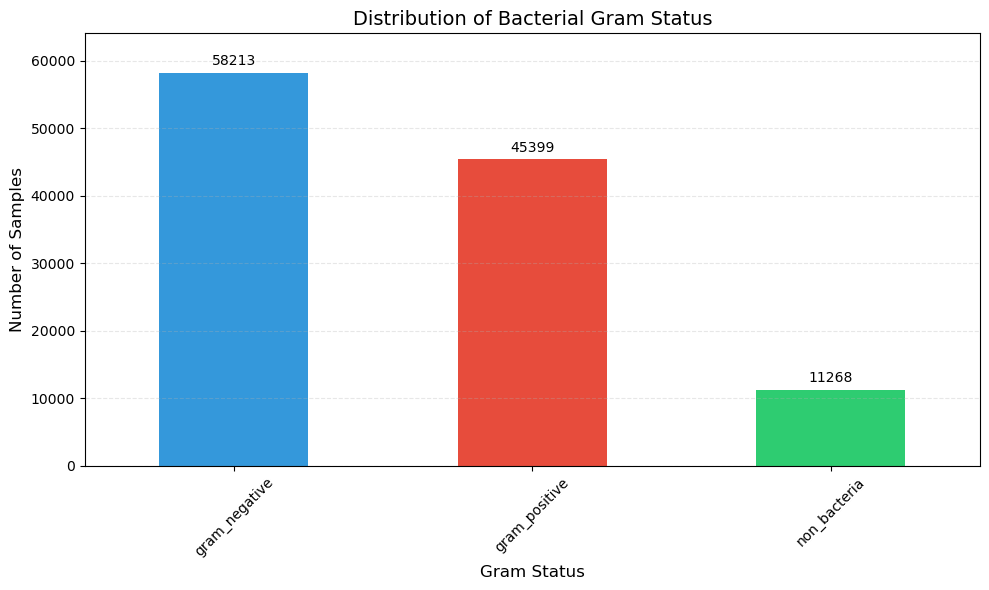

In [4]:
import matplotlib.pyplot as plt

# 5. Plot the distribution
plt.figure(figsize=(10, 6))
counts = amp_df['gram_status'].value_counts().sort_values(ascending=False)

# Create the bar plot and capture the 'ax' object
ax = counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#95a5a6'])

# Add the exact counts on top of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=10)

plt.title('Distribution of Bacterial Gram Status', fontsize=14)
plt.xlabel('Gram Status', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3) # Subtle grid

# Increase the y-axis limit slightly so labels don't touch the top edge
plt.ylim(0, counts.max() * 1.1)

plt.tight_layout()
plt.show()

In [5]:
amp_df[amp_df['gram_status'] == 'non_bacteria']['target_activity_name'].unique()

array(['Candida albicans ATCC 10231',
       'Cryptococcus neoformans ATCC MYA-422',
       'Aspergillus fumigatus ATCC 26430', ...,
       'Saccharomyces cerevisiae SC14395',
       'Schizosaccharomyces pombe SAK950', 'Enterovirus EV-A71'],
      shape=(1049,), dtype=object)

In [6]:
amp_df = amp_df.drop(columns=['target_activity_name'])

In [7]:
amp_df.columns

Index(['sequence', 'activity', 'gram_status'], dtype='object')

In [8]:
amp_df = amp_df[['sequence', 'gram_status', 'activity']]

In [9]:
display(amp_df)

,sequence,gram_status,activity
0,RRXXRF,gram_positive,4.277080
1,RRXXRF,gram_negative,17.108320
2,KVvvKWVvKvVK,gram_positive,165.228990
3,KVvvKWVvKvVK,gram_positive,165.228990
4,KVvvKWVvKvVK,gram_negative,165.228990
...,...,...,...
114875,RxXxR,gram_positive,4.237459
114876,RxXxR,gram_positive,4.237459
114877,RxXxR,gram_positive,16.949835
114878,RxXxR,gram_positive,8.474917


In [10]:
target_classes = ['gram_positive', 'gram_negative']

filtered_df = amp_df[amp_df['gram_status'].isin(target_classes)].copy()

In [11]:
display(filtered_df)

,sequence,gram_status,activity
0,RRXXRF,gram_positive,4.277080
1,RRXXRF,gram_negative,17.108320
2,KVvvKWVvKvVK,gram_positive,165.228990
3,KVvvKWVvKvVK,gram_positive,165.228990
4,KVvvKWVvKvVK,gram_negative,165.228990
...,...,...,...
114875,RxXxR,gram_positive,4.237459
114876,RxXxR,gram_positive,4.237459
114877,RxXxR,gram_positive,16.949835
114878,RxXxR,gram_positive,8.474917


In [12]:
filtered_df.to_csv('../../data/processed/amp_mic_activities_gram_classified.csv', index=False)

In [13]:
filtered_df.isna().sum()

sequence       0
gram_status    0
activity       0
dtype: int64

In [14]:
import numpy as np

filtered_df["log_activity"] = np.log10(filtered_df["activity"].clip(lower=1e-6))

In [15]:
display(filtered_df)

,sequence,gram_status,activity,log_activity
0,RRXXRF,gram_positive,4.277080,0.631147
1,RRXXRF,gram_negative,17.108320,1.233207
2,KVvvKWVvKvVK,gram_positive,165.228990,2.218086
3,KVvvKWVvKvVK,gram_positive,165.228990,2.218086
4,KVvvKWVvKvVK,gram_negative,165.228990,2.218086
...,...,...,...,...
114875,RxXxR,gram_positive,4.237459,0.627105
114876,RxXxR,gram_positive,4.237459,0.627105
114877,RxXxR,gram_positive,16.949835,1.229165
114878,RxXxR,gram_positive,8.474917,0.928135


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

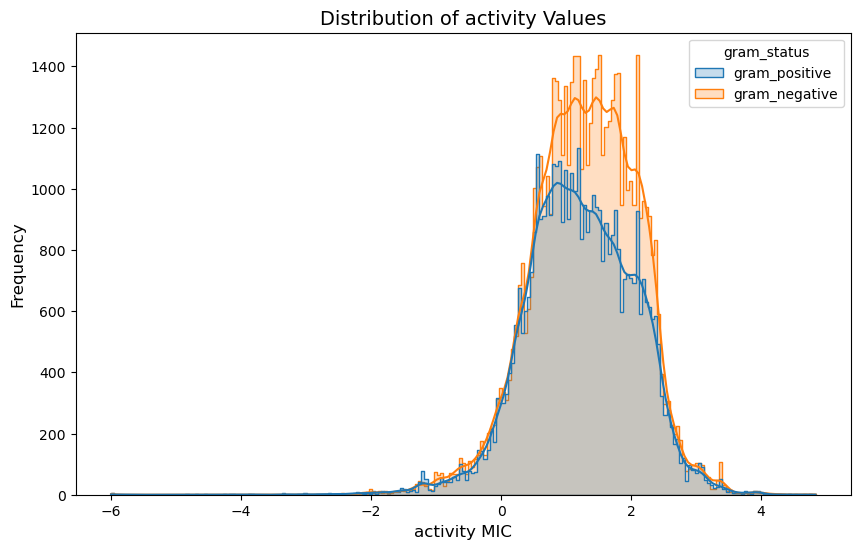

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(data=filtered_df, x='log_activity', hue='gram_status', kde=True, element="step")

plt.title('Distribution of activity Values', fontsize=14)
plt.xlabel('activity MIC', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()